In [14]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

In [16]:
train = pickle.load(open('ECG5000/ECG5000_train.pickle', 'rb'), encoding = 'latin1')
test = pickle.load(open('ECG5000/ECG5000_validation.pickle', 'rb'), encoding = 'latin1')
data = np.concatenate((train, test), axis=0)


# Split features and labels
X = data[:, 1:]
y = data[:, 0]  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape to (samples, timesteps, 1)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Encode labels to 0-based
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

In [18]:
def attention_block(inputs, attention_size):
    """
    A simple attention block to give weights to important regions of the ECG signal.
    This is just a demonstration of a potential attention mechanism in the CNN pipeline.
    """
    attention_probs = layers.Dense(attention_size, activation='softmax')(inputs)
    attention_mul = layers.Multiply()([inputs, attention_probs])
    return attention_mul

def create_attentional_cnn(input_shape, num_classes):
    # Input layer
    inputs = layers.Input(shape=input_shape)

    # First Convolutional Layer
    x = layers.Conv1D(64, 3, activation='relu')(inputs)
    x = layers.MaxPooling1D(2)(x)

    # Attention Layer
    x = attention_block(x, attention_size=64)

    # Second Convolutional Layer
    x = layers.Conv1D(128, 3, activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)

    # Flatten the data for fully connected layer
    x = layers.Flatten()(x)

    # Fully connected layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [24]:
# Define the model
input_shape = (140, 1)  # ECG signal length is 140
num_classes = len(np.unique(y))  # Number of classes in ECG5000 dataset

model = create_attentional_cnn(input_shape, num_classes)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6572 - loss: 1.1452 - val_accuracy: 0.8625 - val_loss: 0.5179
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8850 - loss: 0.3997 - val_accuracy: 0.8800 - val_loss: 0.3769
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9132 - loss: 0.2861 - val_accuracy: 0.9050 - val_loss: 0.3249
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9256 - loss: 0.2391 - val_accuracy: 0.8875 - val_loss: 0.3126
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9206 - loss: 0.2565 - val_accuracy: 0.9075 - val_loss: 0.3086
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9329 - loss: 0.2158 - val_accuracy: 0.9125 - val_loss: 0.2978
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9283 - loss: 0.2379 - val_accuracy: 0.9075 - val_loss: 0.2950
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9447 - loss: 0.1892 - val_accuracy: 0.9125 - v

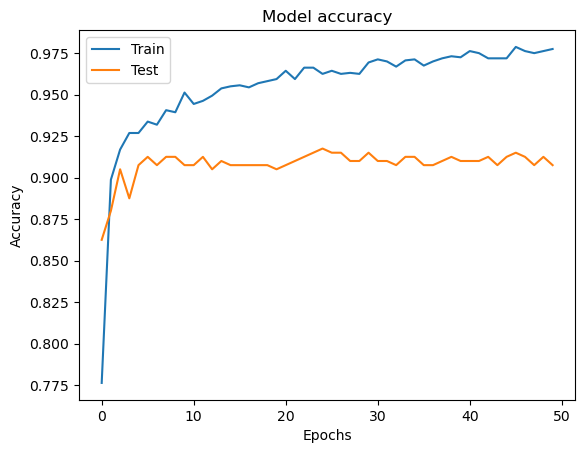

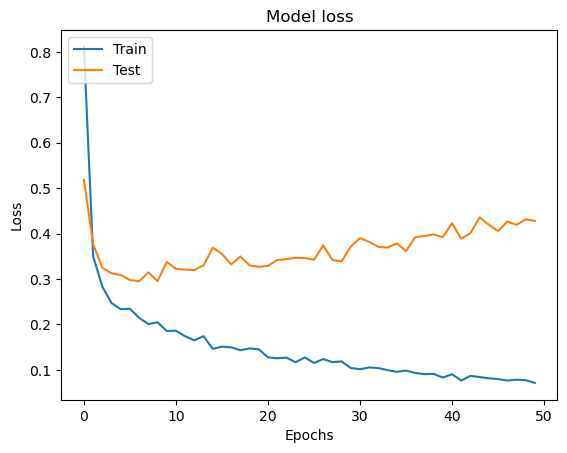

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9198 - loss: 0.3635
Test Accuracy: 0.9075000286102295


In [26]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")